In [1]:
import sys
import os
import shutil
import platform
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt;
# for this course we use locally stored version of pyemu and flopy to avoid version conflicts
import pyemu
import flopy
assert "dependencies" in flopy.__file__
assert "dependencies" in pyemu.__file__
# herebedragons.py contains a series of utility functions that help us manage the tutorial repository
sys.path.insert(0,"..")
import herebedragons as hbd

Setting up MODFLOW files dir

Getting executables to run PEST

In [2]:
# folder containing original model files
org_d = os.path.join('..', '..', '..', "results", '3d_injection_modeling_PMW-6')

# a dir to hold a copy of the org model files
tmp_d = os.path.join('PMW-6_mf6')

if os.path.exists(tmp_d):
    shutil.rmtree(tmp_d)
shutil.copytree(org_d,tmp_d)

# get executables
hbd.prep_bins(tmp_d)
# get dependency folders
hbd.prep_deps(tmp_d)

In [3]:
sim_ws = os.path.join('..', '..', '..', "results", "3d_injection_modeling_PMW-6")
os.listdir(tmp_d)

['heads.csv',
 'inschek.exe',
 'k_layer1.txt',
 'k_layer2.txt',
 'k_layer3.txt',
 'mf5to6.exe',
 'mf6.exe',
 'mfsim.lst',
 'mfsim.nam',
 'MLAC-model.bud',
 'MLAC-model.chd',
 'MLAC-model.dis',
 'MLAC-model.dis.grb',
 'MLAC-model.hds',
 'MLAC-model.ic',
 'MLAC-model.ims',
 'MLAC-model.lst',
 'MLAC-model.nam',
 'MLAC-model.npf',
 'MLAC-model.obs',
 'MLAC-model.oc',
 'MLAC-model.sto',
 'MLAC-model.tdis',
 'MLAC-model.wel',
 'mp7.exe',
 'pest.exe',
 'pestchek.exe',
 'pestpp-da.exe',
 'pestpp-glm.exe',
 'pestpp-ies.exe',
 'pestpp-mou.exe',
 'pestpp-opt.exe',
 'pestpp-sen.exe',
 'pestpp-swp.exe',
 'simulated_data',
 'tempchek.exe',
 'well_location_and_times.csv',
 'zbud6.exe']

Loading MODFLOW simulation to obtain discretization information

In [8]:
sim = flopy.mf6.MFSimulation.load(sim_ws=tmp_d)
gwf = sim.get_model()

#pyemu.os_utils.run("mf6", cwd=tmp_d, verbose=True)

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package mlac-model...


Spatial reference

In [9]:
sr = pyemu.helpers.SpatialReference.from_namfile(
    os.path.join(tmp_d, "mfsim.nam"), 
    delr=gwf.dis.delr.array, 
    delc=gwf.dis.delc.array
)

   could not remove start_datetime


Instantiate PstFrom

In [10]:
template_ws = os.path.join("PMW-6_template") #template directory (PstFrom working folder)
start_datetime = "08/29/2024"

#instantiate PstFrom
pf = pyemu.utils.PstFrom(
    original_d = tmp_d, #where the model is stored
    new_d = template_ws, #where the PEST template will be stored
    longnames = True, #for using PEST/PEST_HP
    spatial_reference = sr, #spatial reference from the model
    zero_based = False, #MODFLOW does not use zero based indices
    start_datetime = start_datetime, #for temporal correlation between parameters
    echo=True, 
    remove_existing=True, #remove existing files in the template directory
)

2025-09-29 12:49:56.245699 starting: opening PstFrom.log for logging
2025-09-29 12:49:56.246704 starting PstFrom process
2025-09-29 12:49:56.265751 starting: setting up dirs
2025-09-29 12:49:56.267789 starting: removing existing new_d 'PMW-6_template'
2025-09-29 12:49:56.623874 finished: removing existing new_d 'PMW-6_template' took: 0:00:00.356085
2025-09-29 12:49:56.624857 starting: copying original_d 'PMW-6_mf6' to new_d 'PMW-6_template'
2025-09-29 12:49:59.032808 finished: copying original_d 'PMW-6_mf6' to new_d 'PMW-6_template' took: 0:00:02.407951
2025-09-29 12:49:59.039803 finished: setting up dirs took: 0:00:02.774052


pf

In [11]:
import flopy.utils.binaryfile as bf
"""
Reads the MODFLOW binary heads file, extracts heads for specified
observation wells at desired times, interpolating between time steps
if necessary, and saves the data to heads.csv.
"""

model_name = "MLAC-model"

file_path = os.path.join(template_ws, 'well_location_and_times.csv')

# --- Load observation info from the CSV file ---
try:
    obs_df = pd.read_csv(file_path)

except FileNotFoundError:
    raise FileNotFoundError("well_locations.csv not found. Did you run create_model.py?")

# Check if the .hds file exists before attempting to read
hds_filepath = os.path.join(template_ws, f'{model_name}.hds')
if not os.path.exists(hds_filepath):
    raise FileNotFoundError(f"Binary heads file not found: {hds_filepath}")

hds_file = bf.HeadFile(hds_filepath)
model_output_times = np.array(hds_file.get_times())

# Get the unique well names and locations
well_locations = obs_df[['well_name', 'layer', 'row', 'col']].drop_duplicates()

# Prepare results storage
interpolated_results = []

for index, obs in obs_df.iterrows():
    well_name = obs['well_name']
    layer, row, col = obs['layer'], obs['row'], obs['col']
    target_time = obs['time']

    # Find the time steps in the model output that bracket the target_time
    # Use np.searchsorted for efficient finding of insertion points
    idx = np.searchsorted(model_output_times, target_time)

    # Handle edge cases: target_time is before the first or after the last model output time
    if idx == 0:
        # Target time is at or before the first model output time.
        # Use the first time step's head.
        # You might want to raise a warning or handle this differently (e.g., extrapolation if allowed).
        t1 = model_output_times[0]
        heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
        interpolated_head = heads_data_t1
        print(f"Warning: Target time {target_time} is before or at first model time {t1}. Using head at {t1}.")

    elif idx == len(model_output_times):
        # Target time is at or after the last model output time.
        # Use the last time step's head.
        # You might want to raise a warning or handle this differently.
        t1 = model_output_times[-1]
        heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
        interpolated_head = heads_data_t1
        print(f"Warning: Target time {target_time} is at or after last model time {t1}. Using head at {t1}.")

    else:
        # Target time is between two model output times or exactly at one.
        t1 = model_output_times[idx - 1]
        t2 = model_output_times[idx]

        if target_time == t1:
            # Exact match for the lower bound
            heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
            interpolated_head = heads_data_t1
        elif target_time == t2:
            # Exact match for the upper bound
            heads_data_t2 = hds_file.get_data(totim=t2)[layer, row, col]
            interpolated_head = heads_data_t2
        else:
            # Interpolate between t1 and t2
            heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
            heads_data_t2 = hds_file.get_data(totim=t2)[layer, row, col]

            # Linear interpolation formula
            interpolated_head = heads_data_t1 + (heads_data_t2 - heads_data_t1) * \
                                (target_time - t1) / (t2 - t1)
    
    interpolated_results.append({
        'time': target_time,
        'well_name': f'HEAD_{well_name}',
        'head': interpolated_head
    })

# Create and pivot the DataFrame
results_df = pd.DataFrame(interpolated_results)

# Pivot the data to have columns for each well name
output_df = results_df.pivot(index='time', columns='well_name', values='head')

# Sort by time, reset index for clean CSV, and ensure consistent output column order
output_df = output_df.sort_index().reset_index()

desired_order = ['time', 'HEAD_PW-1', 'HEAD_PMW-3', 'HEAD_PMW-10', 'HEAD_PMW-14',
                    'HEAD_PW-2', 'HEAD_PMW-9', 'HEAD_PZ-1', 'HEAD_PMW-4', 'HEAD_PMW-5',
                    'HEAD_OW24P', 'HEAD_OW23P', 'HEAD_OW17P']

# Select the columns in the specified order
# Note: If a column is in desired_order but not in output_df, it will be added as NaN.
# If a column is in output_df but not in desired_order, it will be dropped.
try:
    output_df = output_df[desired_order]
except KeyError as e:
    print(f"Warning: A column was not found during reordering: {e}")
    # Continue saving, but without the specified order if it fails

# Write to CSV
output_df.to_csv(os.path.join(template_ws, 'heads.csv'), index=False, float_format='%.16E')
print("heads.csv created with interpolated head data at specified times.")

heads.csv created with interpolated head data at specified times.


Checking data from MODFLOW

In [12]:
#checking the output csv files
for i in [gwf.obs]: 
    print(i.output.obs_names)

['heads.csv']


taking a look at the data file

In [13]:
df_modflow = pd.read_csv(os.path.join(template_ws, "heads.csv"), index_col=0)
df_modflow.head()

,HEAD_PW-1,HEAD_PMW-3,HEAD_PMW-10,HEAD_PMW-14,HEAD_PW-2,HEAD_PMW-9,HEAD_PZ-1,HEAD_PMW-4,HEAD_PMW-5,HEAD_OW24P,HEAD_OW23P,HEAD_OW17P
time,,,,,,,,,,,,
0.010417,0.020916,0.082986,0.099070,0.067635,0.077078,0.019033,0.045098,0.009717,0.026818,0.026691,0.110870,0.016515
0.020833,0.046839,0.123527,0.140921,0.106017,0.116659,0.044048,0.079158,0.028729,0.056122,0.056204,0.154632,0.040597
0.041667,0.081487,0.166799,0.184479,0.147901,0.159087,0.078432,0.118614,0.058585,0.092631,0.092736,0.199044,0.074118
0.062500,0.103825,0.192060,0.209663,0.172646,0.183869,0.100882,0.142682,0.079221,0.115362,0.114763,0.224219,0.095499


Taking a look at the field data

In [14]:
df_field = pd.read_csv("../../../data/PMW-6_t.csv", index_col=0)
df_field.head()

,HEAD_PW-1,HEAD_PMW-3,HEAD_PMW-10,HEAD_PMW-14,HEAD_PW-2,HEAD_PMW-9,HEAD_PZ-1,HEAD_PMW-4,HEAD_PMW-5,HEAD_OW24P,HEAD_OW23P,HEAD_OW17P
time,,,,,,,,,,,,
0.010417,0.009313,0.139853,0.005000,0.110165,0.00136,0.000,0.019109,-0.002393,0.006000,0.003426,0.021026,0.005726
0.020833,0.035997,0.203853,0.028999,0.180839,-0.00022,-0.001,0.063277,0.005620,0.030998,0.009688,0.045382,0.016650
0.041667,0.123661,0.282903,0.109995,0.260987,-0.00391,0.001,0.149909,0.025665,0.096995,0.013416,0.075830,0.033832
0.062500,0.184743,0.329537,0.170992,0.307138,0.00139,0.003,0.197710,0.045378,0.147993,0.025560,0.094278,0.050680


Both have the same order of wells

In [17]:
df_modflow.columns.values == df_field.columns.values

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

copying over the field data to our template folder. starting heads.csv will be the field data that will be used to add observation data in the PEST control file. during the PEST iterations, MODFLOW + processing code will overwrite this file with the current iteration simulation output. 

In [20]:
shutil.copy2(
    src="../../../data/PMW-6_t.csv",
    dst=os.path.join(template_ws, "heads.csv")
)

shutil.copy(
    src="../../../data/PMW-6_t.csv",
    dst=os.path.join(template_ws, "PMW-6_t.csv")
)

'PMW-6_template\\PMW-6_t.csv'

Adding field observation to pst

In [19]:
hds_df = pf.add_observations(
    "heads.csv", #data file to read
    insfile="heads.csv.ins", #instruction file name
    index_cols="time", #column header to use as index
    use_cols=list(df_field.columns.values), #name of columns that includes observation values
    #prefix="hds" #prefix to all observation names
    #obsnam_dict={"head_pw1": "pw1"}
)

2025-09-29 12:54:26.973946 starting: adding observations from output file heads.csv
2025-09-29 12:54:26.975700 starting: adding observations from tabular output file '['heads.csv']'
2025-09-29 12:54:26.978987 starting: reading list-style file: PMW-6_template\heads.csv
2025-09-29 12:54:26.990533 finished: reading list-style file: PMW-6_template\heads.csv took: 0:00:00.011546
2025-09-29 12:54:27.000574 starting: building insfile for tabular output file heads.csv
2025-09-29 12:54:27.037559 finished: building insfile for tabular output file heads.csv took: 0:00:00.036985
2025-09-29 12:54:27.038564 starting: adding observation from instruction file 'PMW-6_template\heads.csv.ins'
2025-09-29 12:54:27.189772 finished: adding observation from instruction file 'PMW-6_template\heads.csv.ins' took: 0:00:00.151208
2025-09-29 12:54:27.196779 finished: adding observations from tabular output file '['heads.csv']' took: 0:00:00.221079
2025-09-29 12:54:27.198784 finished: adding observations from output

In [22]:
hds_df.head()

,obsnme,obsval,weight,obgnme
oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,0.005726,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p
oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,0.016650,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p
oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,0.033832,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p
oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,0.050680,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p
oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,0.021026,1.0,oname:heads.csv_otype:lst_usecol:head_ow23p


instruction  file has been created in the template folder

In [23]:
[f for f in os.listdir(template_ws) if f.endswith(".ins")]

['heads.csv.ins']

Currently MODFLOW model has no idomain which will be used to inactivate some cells above the below BPP to simulate the packer. Since the current model only has 3 layers, I am not inactivating it yet, so we can collect data above the BPP

In [24]:
#get the IDOMAIN array
ib = gwf.dis.idomain.array[0]

plt.imshow(ib)
plt.colorbar()

TypeError: 'NoneType' object is not subscriptable

Adding the parameters: 3 constant K layers

In [26]:
df_cst = pf.add_parameters(
    "k_layer1.txt", 
    par_type='constant', 
    par_name_base="k_layer1", 
    pargp="k_layer1", 
    initial_value=gwf.npf.k.array[0][0][0],
    lower_bound=0.01, upper_bound=1000, 
    ult_ubound=1000, ult_lbound=0.001, 
    )

2025-09-29 12:58:37.533107 transform was not passed, setting default tranform to 'log'
2025-09-29 12:58:37.536150 starting: adding constant type m style parameters for file(s) ['k_layer1.txt']
2025-09-29 12:58:37.539099 starting: loading array PMW-6_template\k_layer1.txt
2025-09-29 12:58:37.763656 finished: loading array PMW-6_template\k_layer1.txt took: 0:00:00.224557
2025-09-29 12:58:37.763656 loaded array 'PMW-6_mf6\k_layer1.txt' of shape (388, 388)
2025-09-29 12:58:38.041477 starting: writing array-style template file 'PMW-6_template\k_layer1_inst0_constant.csv.tpl'
2025-09-29 12:58:38.042501 starting: writing template file PMW-6_template\k_layer1_inst0_constant.csv.tpl for ['k_layer1_inst:0']
2025-09-29 12:58:40.281653 finished: writing template file PMW-6_template\k_layer1_inst0_constant.csv.tpl for ['k_layer1_inst:0'] took: 0:00:02.239152
2025-09-29 12:58:40.283647 starting: writing array-based template file 'PMW-6_template\k_layer1_inst0_constant.csv.tpl'
2025-09-29 12:58:40.46

In [27]:
df_cst = pf.add_parameters(
    "k_layer2.txt", 
    par_type='constant', 
    par_name_base="k_layer2", 
    pargp="k_layer2", 
    initial_value=gwf.npf.k.array[1][0][0],
    lower_bound=0.01, upper_bound=1000, 
    ult_ubound=1000, ult_lbound=0.001, 
    )

2025-09-29 12:58:44.453154 transform was not passed, setting default tranform to 'log'
2025-09-29 12:58:44.454168 starting: adding constant type m style parameters for file(s) ['k_layer2.txt']
2025-09-29 12:58:44.454168 starting: loading array PMW-6_template\k_layer2.txt
2025-09-29 12:58:44.519508 finished: loading array PMW-6_template\k_layer2.txt took: 0:00:00.065340
2025-09-29 12:58:44.519508 loaded array 'PMW-6_mf6\k_layer2.txt' of shape (388, 388)
2025-09-29 12:58:44.799101 starting: writing array-style template file 'PMW-6_template\k_layer2_inst0_constant.csv.tpl'
2025-09-29 12:58:44.801103 starting: writing template file PMW-6_template\k_layer2_inst0_constant.csv.tpl for ['k_layer2_inst:0']
2025-09-29 12:58:46.613944 finished: writing template file PMW-6_template\k_layer2_inst0_constant.csv.tpl for ['k_layer2_inst:0'] took: 0:00:01.812841
2025-09-29 12:58:46.614926 starting: writing array-based template file 'PMW-6_template\k_layer2_inst0_constant.csv.tpl'
2025-09-29 12:58:46.72

In [28]:
df_cst = pf.add_parameters(
    "k_layer3.txt", 
    par_type='constant', 
    par_name_base="k_layer3", 
    pargp="k_layer3", 
    initial_value=gwf.npf.k.array[2][0][0],
    lower_bound=0.01, upper_bound=1000, 
    ult_ubound=1000, ult_lbound=0.001, 
    )

2025-09-29 12:58:49.637153 transform was not passed, setting default tranform to 'log'
2025-09-29 12:58:49.639150 starting: adding constant type m style parameters for file(s) ['k_layer3.txt']
2025-09-29 12:58:49.640154 starting: loading array PMW-6_template\k_layer3.txt
2025-09-29 12:58:49.770952 finished: loading array PMW-6_template\k_layer3.txt took: 0:00:00.130798
2025-09-29 12:58:49.771945 loaded array 'PMW-6_mf6\k_layer3.txt' of shape (388, 388)
2025-09-29 12:58:50.113494 starting: writing array-style template file 'PMW-6_template\k_layer3_inst0_constant.csv.tpl'
2025-09-29 12:58:50.114495 starting: writing template file PMW-6_template\k_layer3_inst0_constant.csv.tpl for ['k_layer3_inst:0']
2025-09-29 12:58:52.288619 finished: writing template file PMW-6_template\k_layer3_inst0_constant.csv.tpl for ['k_layer3_inst:0'] took: 0:00:02.174124
2025-09-29 12:58:52.290624 starting: writing array-based template file 'PMW-6_template\k_layer3_inst0_constant.csv.tpl'
2025-09-29 12:58:52.42

building pst

In [29]:
pst = pf.build_pst()

noptmax:0, npar_adj:3, nnz_obs:48


checking parameter groups and data

In [30]:
pst.parameter_groups

,pargpnme,inctyp,derinc,derinclb,forcen,derincmul,dermthd,splitthresh,splitreldiff,splitaction
pargpnme,,,,,,,,,,
k_layer1,k_layer1,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
k_layer2,k_layer2,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
k_layer3,k_layer3,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller


In [31]:
pst.parameter_data

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,inst,pname,pstyle,ptype
pname:k_layer1_inst:0_ptype:cn_pstyle:m,pname:k_layer1_inst:0_ptype:cn_pstyle:m,log,factor,2.9869,0.01,1000,k_layer1,1.0,0.0,1,0,k,m,cn
pname:k_layer2_inst:0_ptype:cn_pstyle:m,pname:k_layer2_inst:0_ptype:cn_pstyle:m,log,factor,1.8157,0.01,1000,k_layer2,1.0,0.0,1,0,k,m,cn
pname:k_layer3_inst:0_ptype:cn_pstyle:m,pname:k_layer3_inst:0_ptype:cn_pstyle:m,log,factor,12.9893,0.01,1000,k_layer3,1.0,0.0,1,0,k,m,cn


adding mf6 executable code in the PEST running script

In [32]:
pf.mod_sys_cmds.append("mf6") #do this only once
pf.mod_sys_cmds

['mf6']

adding the processing MODFLOW output in the PEST running script. 

This processing script reads the MODFLOW simulation output (heads for all well in all simulation time steps), and sample heads only for desired times (i.e. times that we have field data) using interpolation, then overwrites the heads.csv (MODFLOW output) used to compared with the observation data added to the PEST control file.

In [33]:
pf.add_py_function("helpers.py","process_heads_csv()",is_pre_cmd=False)

building pst and printing the PEST running script

In [34]:
pst = pf.build_pst()

_ = [print(line.rstrip()) for line in open(os.path.join(template_ws,"forward_run.py"))]

noptmax:0, npar_adj:3, nnz_obs:48
2025-09-29 13:04:10.068182 forward_run line:pyemu.os_utils.run(r'mf6')

import os
import multiprocessing as mp
import numpy as np
import pandas as pd
import pyemu

# function added thru PstFrom.add_py_function()
def process_heads_csv(model_name="MLAC-model"):
    import flopy.utils.binaryfile as bf
    """
    Reads the MODFLOW binary heads file, extracts heads for specified
    observation wells at desired times, interpolating between time steps
    if necessary, and saves the data to heads.csv.
    """

    model_ws = "."

    file_path = os.path.join(model_ws, 'well_location_and_times.csv')

    # --- Load observation info from the CSV file ---
    try:
        obs_df = pd.read_csv(file_path)

    except FileNotFoundError:
        raise FileNotFoundError("well_locations.csv not found. Did you run create_model.py?")

    # Check if the .hds file exists before attempting to read
    hds_filepath = os.path.join(model_ws, f'{model_name}.hds')
    if not

updating the maximum number of PEST iteration

In [35]:
pst.control_data.noptmax = 15
pst.control_data.noptmax

15

In [36]:
print(f'there are {pst.nobs} field observation')

there are 48 field observation


changing observation names to meet the PEST version 1 character limit

In [38]:
print('current observation names:')
pst.obs_names

current observation names:


['oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.010417',
 'oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.020833',
 'oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.041667',
 'oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.0625',
 'oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.010417',
 'oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.020833',
 'oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.041667',
 'oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.0625',
 'oname:heads.csv_otype:lst_usecol:head_ow24p_time:0.010417',
 'oname:heads.csv_otype:lst_usecol:head_ow24p_time:0.020833',
 'oname:heads.csv_otype:lst_usecol:head_ow24p_time:0.041667',
 'oname:heads.csv_otype:lst_usecol:head_ow24p_time:0.0625',
 'oname:heads.csv_otype:lst_usecol:head_pmw-10_time:0.010417',
 'oname:heads.csv_otype:lst_usecol:head_pmw-10_time:0.020833',
 'oname:heads.csv_otype:lst_usecol:head_pmw-10_time:0.041667',
 'oname:heads.csv_otype:lst_usecol:head_pmw-10_time:0.0625',
 'oname:head

In [39]:
new_obs_names_dict = {name: name[38:] for name in pst.obs_names}
pst.rename_observations(new_obs_names_dict,
                        pst_path=template_ws
                        )

In [40]:
print('new observation names:')
pst.obs_names

new observation names:


['ow17p_time:0.010417',
 'ow17p_time:0.020833',
 'ow17p_time:0.041667',
 'ow17p_time:0.0625',
 'ow23p_time:0.010417',
 'ow23p_time:0.020833',
 'ow23p_time:0.041667',
 'ow23p_time:0.0625',
 'ow24p_time:0.010417',
 'ow24p_time:0.020833',
 'ow24p_time:0.041667',
 'ow24p_time:0.0625',
 'pmw-10_time:0.010417',
 'pmw-10_time:0.020833',
 'pmw-10_time:0.041667',
 'pmw-10_time:0.0625',
 'pmw-14_time:0.010417',
 'pmw-14_time:0.020833',
 'pmw-14_time:0.041667',
 'pmw-14_time:0.0625',
 'pmw-3_time:0.010417',
 'pmw-3_time:0.020833',
 'pmw-3_time:0.041667',
 'pmw-3_time:0.0625',
 'pmw-4_time:0.010417',
 'pmw-4_time:0.020833',
 'pmw-4_time:0.041667',
 'pmw-4_time:0.0625',
 'pmw-5_time:0.010417',
 'pmw-5_time:0.020833',
 'pmw-5_time:0.041667',
 'pmw-5_time:0.0625',
 'pmw-9_time:0.010417',
 'pmw-9_time:0.020833',
 'pmw-9_time:0.041667',
 'pmw-9_time:0.0625',
 'pw-1_time:0.010417',
 'pw-1_time:0.020833',
 'pw-1_time:0.041667',
 'pw-1_time:0.0625',
 'pw-2_time:0.010417',
 'pw-2_time:0.020833',
 'pw-2_tim

Changing observation group names

Each observation group correspond to a well in a injection test. So observation in the same well (and zone) during the same injection test are grouped together

In [41]:
print('old observation group names:')
pst.obs_groups

old observation group names:


['oname:heads.csv_otype:lst_usecol:head_ow17p',
 'oname:heads.csv_otype:lst_usecol:head_ow23p',
 'oname:heads.csv_otype:lst_usecol:head_ow24p',
 'oname:heads.csv_otype:lst_usecol:head_pmw-10',
 'oname:heads.csv_otype:lst_usecol:head_pmw-14',
 'oname:heads.csv_otype:lst_usecol:head_pmw-3',
 'oname:heads.csv_otype:lst_usecol:head_pmw-4',
 'oname:heads.csv_otype:lst_usecol:head_pmw-5',
 'oname:heads.csv_otype:lst_usecol:head_pmw-9',
 'oname:heads.csv_otype:lst_usecol:head_pw-1',
 'oname:heads.csv_otype:lst_usecol:head_pw-2',
 'oname:heads.csv_otype:lst_usecol:head_pz-1']

In [42]:
pst.observation_data.head()

,obsnme,obsval,weight,obgnme,oname,otype,time,usecol
ow17p_time:0.010417,ow17p_time:0.010417,0.005726,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p,heads.csv,lst,0.010417,head
ow17p_time:0.020833,ow17p_time:0.020833,0.016650,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p,heads.csv,lst,0.020833,head
ow17p_time:0.041667,ow17p_time:0.041667,0.033832,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p,heads.csv,lst,0.041667,head
ow17p_time:0.0625,ow17p_time:0.0625,0.050680,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p,heads.csv,lst,0.0625,head
ow23p_time:0.010417,ow23p_time:0.010417,0.021026,1.0,oname:heads.csv_otype:lst_usecol:head_ow23p,heads.csv,lst,0.010417,head


updated names

In [43]:
group_mapping = {old: f'inj_pmw-6_{old[33:]}' for old in pst.obs_groups}

pst.observation_data['obgnme'] = pst.observation_data['obgnme'].map(group_mapping)
pst.observation_data.head()

,obsnme,obsval,weight,obgnme,oname,otype,time,usecol
ow17p_time:0.010417,ow17p_time:0.010417,0.005726,1.0,inj_pmw-6_head_ow17p,heads.csv,lst,0.010417,head
ow17p_time:0.020833,ow17p_time:0.020833,0.016650,1.0,inj_pmw-6_head_ow17p,heads.csv,lst,0.020833,head
ow17p_time:0.041667,ow17p_time:0.041667,0.033832,1.0,inj_pmw-6_head_ow17p,heads.csv,lst,0.041667,head
ow17p_time:0.0625,ow17p_time:0.0625,0.050680,1.0,inj_pmw-6_head_ow17p,heads.csv,lst,0.0625,head
ow23p_time:0.010417,ow23p_time:0.010417,0.021026,1.0,inj_pmw-6_head_ow23p,heads.csv,lst,0.010417,head


taking a look at the parameter data and renaming it

In [44]:
#renaming parameters
pst.parameter_data

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,inst,pname,pstyle,ptype
pname:k_layer1_inst:0_ptype:cn_pstyle:m,pname:k_layer1_inst:0_ptype:cn_pstyle:m,log,factor,2.9869,0.01,1000,k_layer1,1.0,0.0,1,0,k,m,cn
pname:k_layer2_inst:0_ptype:cn_pstyle:m,pname:k_layer2_inst:0_ptype:cn_pstyle:m,log,factor,1.8157,0.01,1000,k_layer2,1.0,0.0,1,0,k,m,cn
pname:k_layer3_inst:0_ptype:cn_pstyle:m,pname:k_layer3_inst:0_ptype:cn_pstyle:m,log,factor,12.9893,0.01,1000,k_layer3,1.0,0.0,1,0,k,m,cn


In [45]:
new_par_names_dict = {pst.par_names[i]:f'k_{i+1}' for i in range(len(pst.par_names))}
print('old and new parameter names: ')
new_par_names_dict

old and new parameter names: 


{'pname:k_layer1_inst:0_ptype:cn_pstyle:m': 'k_1',
 'pname:k_layer2_inst:0_ptype:cn_pstyle:m': 'k_2',
 'pname:k_layer3_inst:0_ptype:cn_pstyle:m': 'k_3'}

In [46]:
pst.rename_parameters(new_par_names_dict,
                        pst_path=template_ws
                        )
pst.parameter_data

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,inst,pname,pstyle,ptype
k_1,k_1,log,factor,2.9869,0.01,1000,k_layer1,1.0,0.0,1,0,k,m,cn
k_2,k_2,log,factor,1.8157,0.01,1000,k_layer2,1.0,0.0,1,0,k,m,cn
k_3,k_3,log,factor,12.9893,0.01,1000,k_layer3,1.0,0.0,1,0,k,m,cn


Checking input and output model files

In [47]:
pst.model_input_data

,pest_file,model_file
k_layer1_inst0_constant.csv.tpl,k_layer1_inst0_constant.csv.tpl,mult\k_layer1_inst0_constant.csv
k_layer2_inst0_constant.csv.tpl,k_layer2_inst0_constant.csv.tpl,mult\k_layer2_inst0_constant.csv
k_layer3_inst0_constant.csv.tpl,k_layer3_inst0_constant.csv.tpl,mult\k_layer3_inst0_constant.csv


In [48]:
pst.model_output_data

,pest_file,model_file
heads.csv.ins,heads.csv.ins,heads.csv


overwritting pst file

In [49]:
pst.write(os.path.join(template_ws, 'PMW-6_mf6.pst'),version=1)

noptmax:15, npar_adj:3, nnz_obs:48


Running PEST

In [50]:
pyemu.os_utils.run('pestpp-glm PMW-6_mf6.pst', cwd=template_ws, verbose=True)

run():pestpp-glm.exe PMW-6_mf6.pst


plotting results

In [51]:
df_obj = pd.read_csv(os.path.join(template_ws, "PMW-6_mf6.iobj"),index_col=0)
# echo out the dataframe
df_obj

,model_runs_completed,total_phi,measurement_phi,regularization_phi,inj_pmw-6_head_ow17p,inj_pmw-6_head_ow23p,inj_pmw-6_head_ow24p,inj_pmw-6_head_pmw-10,inj_pmw-6_head_pmw-14,inj_pmw-6_head_pmw-3,inj_pmw-6_head_pmw-4,inj_pmw-6_head_pmw-5,inj_pmw-6_head_pmw-9,inj_pmw-6_head_pw-1,inj_pmw-6_head_pw-2,inj_pmw-6_head_pz-1
iteration,,,,,,,,,,,,,,,,
0,0,0.642894,0.642894,0,0.003839,0.013537,0.000797,0.037933,0.199701,0.238939,0.002707,0.031547,0.000009,0.050113,0.000143,0.063630
1,19,0.584929,0.584929,0,0.002644,0.009359,0.000318,0.032466,0.184749,0.220677,0.002146,0.027920,0.000143,0.046215,0.000918,0.057375
2,40,0.547822,0.547822,0,0.001861,0.007439,0.000160,0.028960,0.175370,0.210596,0.001536,0.024955,0.000435,0.042358,0.001687,0.052465
3,67,0.279193,0.279193,0,0.002485,0.022659,0.011283,0.014380,0.062969,0.072823,0.001844,0.004443,0.012389,0.013677,0.049067,0.011174
4,97,0.277194,0.277194,0,0.002560,0.023542,0.011498,0.014550,0.061120,0.070773,0.001976,0.004133,0.013109,0.012929,0.050548,0.010456
5,127,0.277194,0.277194,0,0.002560,0.023541,0.011498,0.014550,0.061121,0.070773,0.001976,0.004133,0.013109,0.012929,0.050548,0.010456


array([<Axes: xlabel='iteration'>, <Axes: xlabel='iteration'>],
      dtype=object)

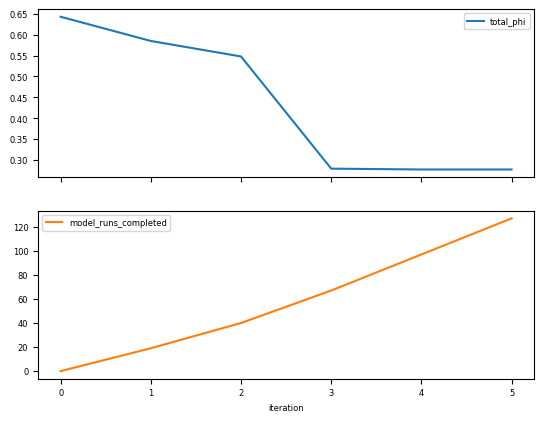

In [52]:
df_obj.loc[:,["total_phi","model_runs_completed"]].plot(subplots=True)

Estimated K values:

In [56]:
pst.parameter_data.parval1

k_1     2.9869
k_2     1.8157
k_3    12.9893
Name: parval1, dtype: float64

In [61]:
estimated_parameters = pst.parameter_data.copy()
10**(estimated_parameters.loc[estimated_parameters['partrans'] == 'log', 'parval1'])


k_1    9.702865e+02
k_2    6.541841e+01
k_3    9.756634e+12
Name: parval1, dtype: float64

plotting head results

In [53]:
res_nz = pst.res.loc[pst.nnz_obs_names,:]
# display res_nz to understand what we are doing
res_nz.head(4)

,name,group,measured,modelled,residual,weight
name,,,,,,
ow17p_time:0.010417,ow17p_time:0.010417,inj_pmw-6_head_ow17p,0.005726,0.019330,-0.013603,1.0
ow17p_time:0.020833,ow17p_time:0.020833,inj_pmw-6_head_ow17p,0.016650,0.039977,-0.023327,1.0
ow17p_time:0.041667,ow17p_time:0.041667,inj_pmw-6_head_ow17p,0.033832,0.064870,-0.031039,1.0
ow17p_time:0.0625,ow17p_time:0.0625,inj_pmw-6_head_ow17p,0.050680,0.080136,-0.029456,1.0


<Figure size 800x1050 with 0 Axes>

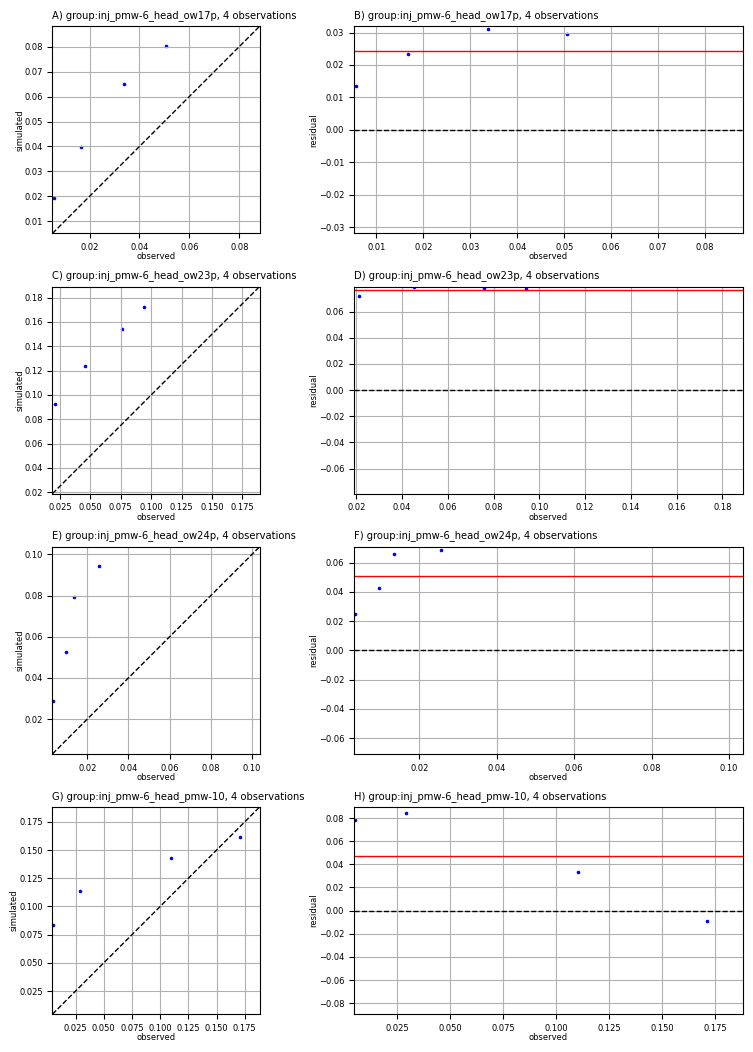

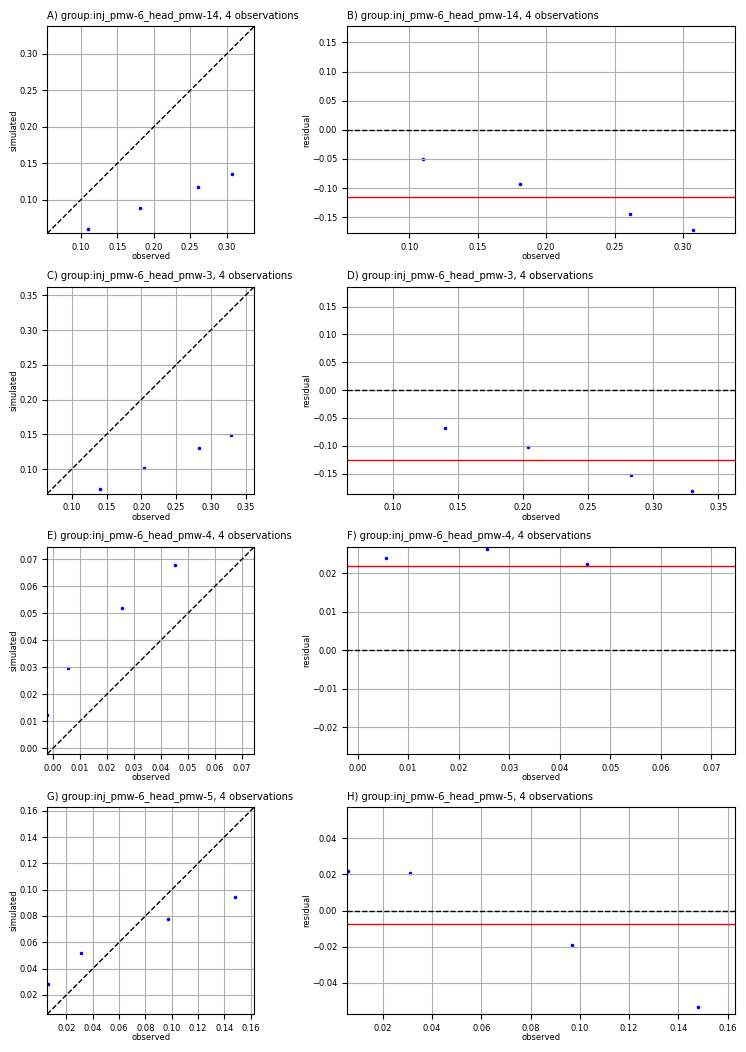

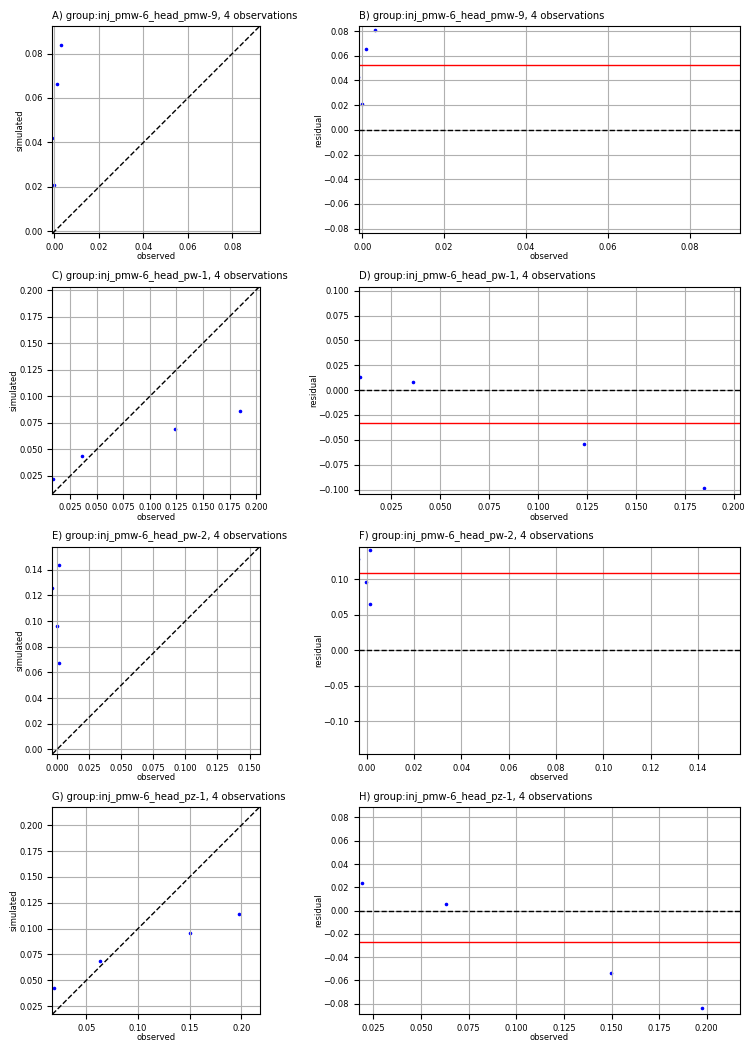

In [54]:
pyemu.plot_utils.res_1to1(pst);

debugging